# Graphing Video Game Sales

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
sns.set_theme()

In [5]:
games = pd.read_csv('top100videogamesales.csv')
games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Nintendo,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Mario Kart Wii,Nintendo,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
2,3,Wii Sports Resort,Nintendo,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
3,4,New Super Mario Bros.,Nintendo,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
4,5,Wii Play,Nintendo,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02


In [6]:
games.info()
# games.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          100 non-null    int64  
 1   Name          100 non-null    object 
 2   Platform      100 non-null    object 
 3   Year          100 non-null    int64  
 4   Genre         100 non-null    object 
 5   Publisher     100 non-null    object 
 6   NA_Sales      100 non-null    float64
 7   EU_Sales      100 non-null    float64
 8   JP_Sales      100 non-null    float64
 9   Other_Sales   100 non-null    float64
 10  Global_Sales  100 non-null    float64
dtypes: float64(5), int64(2), object(4)
memory usage: 8.7+ KB


# Regional Sales by Publisher

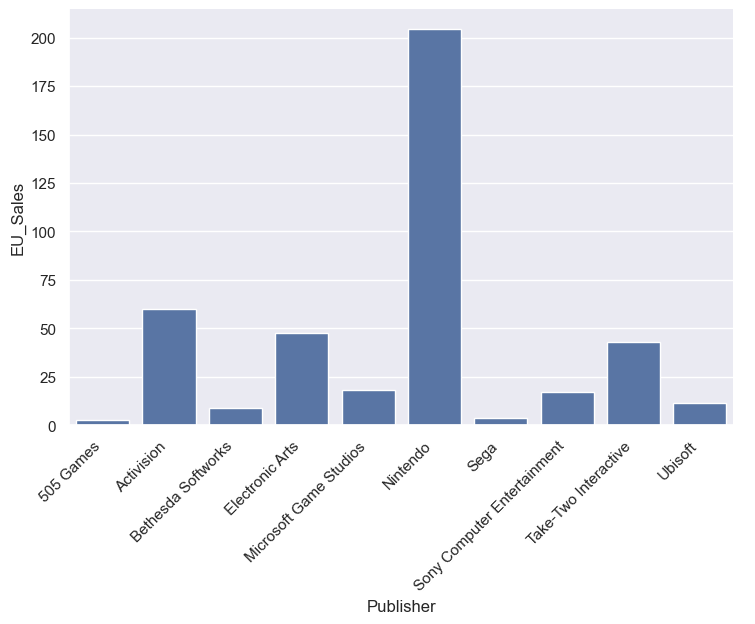

In [7]:
regional_sales = games.groupby('Publisher')['EU_Sales'].sum().reset_index()
sales_plot = sns.catplot(kind='bar', data=regional_sales, x= 'Publisher', y='EU_Sales', height = 5, aspect=1.5)
sales_plot.set_xticklabels(rotation=45, horizontalalignment='right')

# Global Sales by Year

<Axes: xlabel='Year', ylabel='Global_Sales'>

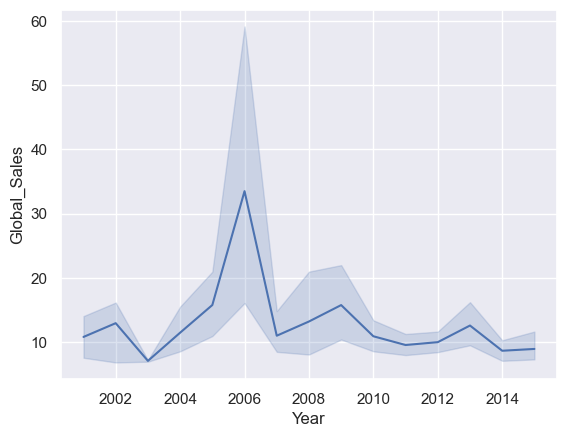

In [8]:
sns.lineplot(data=games, x='Year', y= 'Global_Sales')

# Global Sales Distribution for Action Games

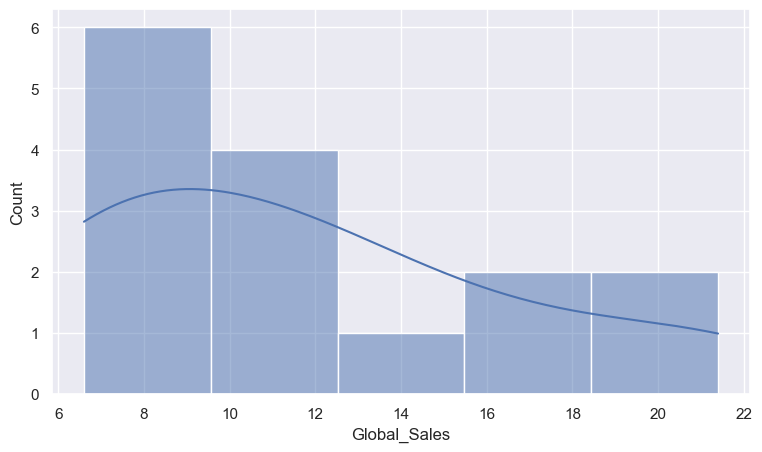

In [9]:
action_games = games[games['Genre']=='Action']

plt.figure(figsize=(9,5))
sns.histplot(data=action_games, x='Global_Sales',kde=True)
plt.show()


# North American Sales by Genre

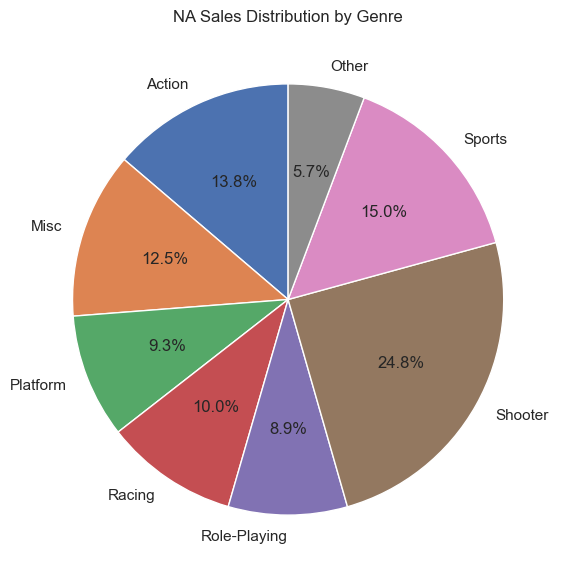

In [10]:
NA_sales = games.groupby('Genre')['NA_Sales'].sum()
threshold = NA_sales.sum() * 0.05
main = NA_sales[NA_sales >=threshold].copy()
other = NA_sales[NA_sales < threshold]
main['Other']= other.sum()

plt.figure(figsize=(10,7))
plt.pie(main, labels=main.index, autopct='%1.1f%%', startangle=90)
plt.title('NA Sales Distribution by Genre')
plt.show()

# European Sales by Genre

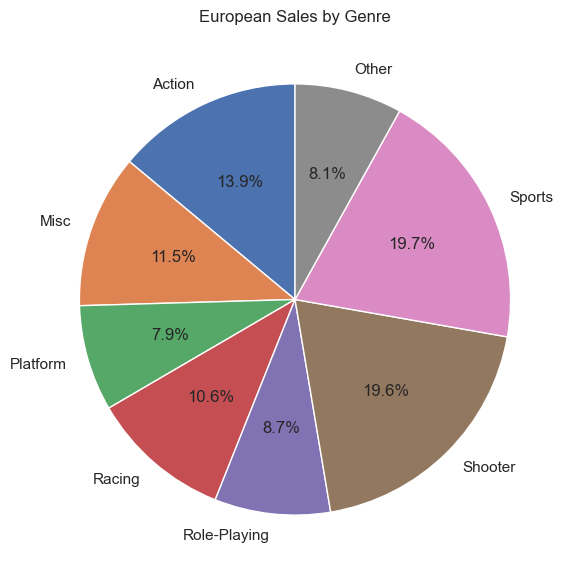

In [33]:
EA_Sales = games.groupby('Genre')['EU_Sales'].sum()
threshold = EA_Sales.sum() * 0.06
main = EA_Sales[EA_Sales >=threshold].copy()
other = EA_Sales[EA_Sales < threshold]
main['Other'] = other.sum()

plt.figure(figsize=(10,7))
plt.pie(main, labels=main.index, autopct='%1.1f%%', startangle=90)
plt.title('European Sales by Genre')
plt.show()

# Count of Games by Platform
Looking at the chart below, Nitendo being the most used platform, followed by Playstationa and xbox respectively.

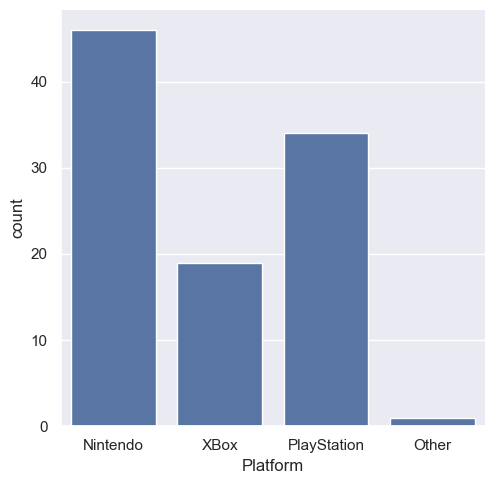

In [11]:
sns.catplot(kind='count', data=games , x='Platform')

# What genre of game is present the most in the top 100 games from 2000-2015?

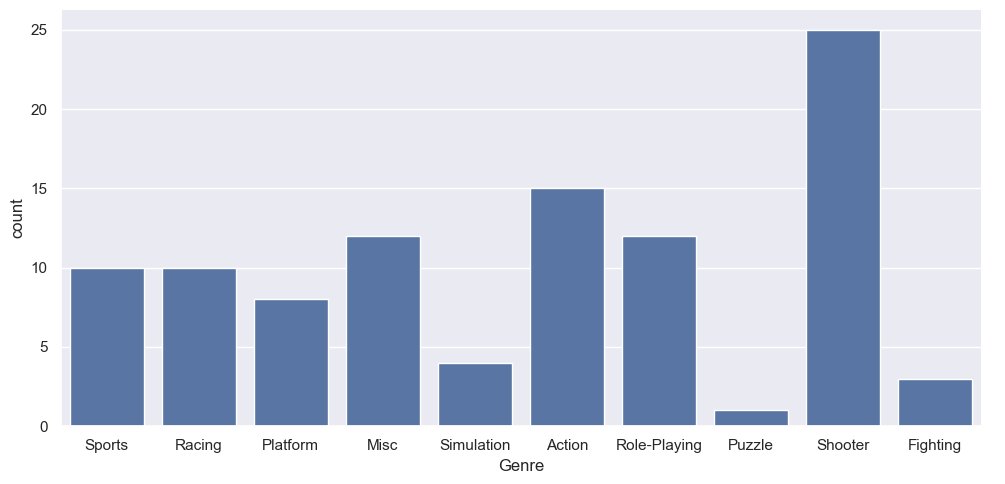

In [12]:
sns.catplot(kind='count', data=games, x= 'Genre', aspect=2)

# What percentage of global sales does PlayStation have in the dataset?
The percentage of playstation in Global Sales is **27.1%** making it the second highest in the Global sales

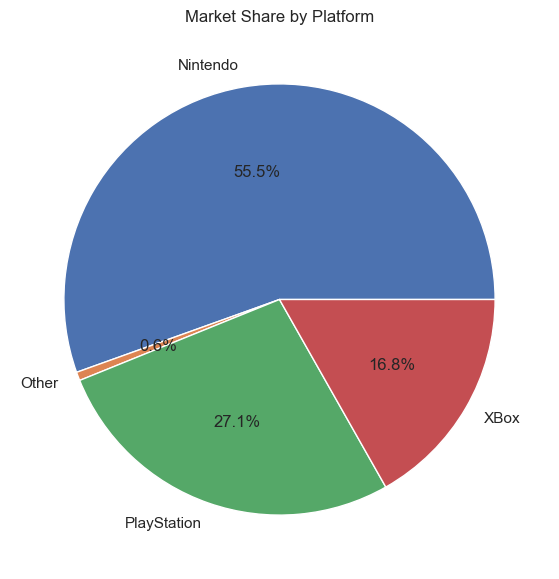

In [26]:
playstation = games.groupby('Platform').agg({'Global_Sales': 'sum'})
total_sales = playstation['Global_Sales'].sum()
playstation['Percentage'] = round((playstation['Global_Sales']/total_sales) * 100)
# playstation.head()
plt.figure(figsize=(10, 7))
plt.pie(playstation['Global_Sales'], 
        labels=playstation.index, 
        autopct='%1.1f%%', 
        ) 

plt.title('Market Share by Platform')
plt.show()

# What is the distribution of sales for Shooter games?


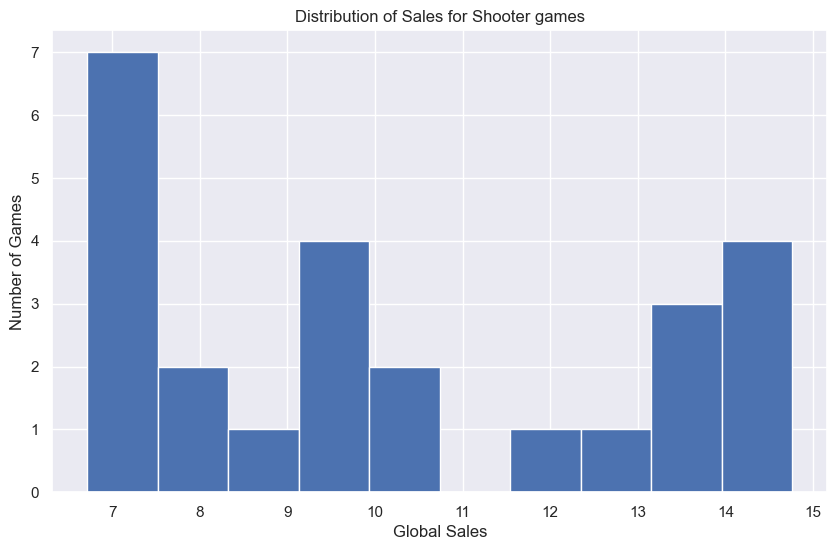

In [30]:
shooter_games = games[games['Genre']=='Shooter']
plt.figure(figsize=(10,6))
plt.hist(shooter_games['Global_Sales'], bins=10)
plt.title('Distribution of Sales for Shooter games')
plt.xlabel('Global Sales')
plt.ylabel('Number of Games')
plt.show()